In [1]:
pathout = ".."

import sys
sys.path.append(pathout)
from TheModel import *

In [2]:
epsi=.005
C=15
alpha=.08
tmax=5*360
mmax=0
s=0

p = {
        'y0':[1-epsi,0,0,epsi,0,0,0,0,0,0,0],
        'beta': C*alpha,
        'alpha': alpha,
        'gamma': .1,
        'nu': .01,
        'tmin': 0,
        'tmax': tmax,
        'stepsize': 0.1,      
        'maxstep': 10,
        'direction': True,
        's': s,              # seasonality amplitude
        'w': 2*np.pi/360,        # seasonality frequency (repeats after every 360days)
        'seasonalshift': 0,
        'mmax': mmax, #0.845,
        'hthres': 2*1/1000,
        'epsilon_m': 2*0.00025,
        'tau': 36,
        'distinguishable': False,
    }

###############################
InInfComp = 'A and B' ######### 'A and B' or 'AB' Doesnt change anything because we start at alpha=0.12 away from the basin boarder 
###############################

# ANALYSIS: Symmetric Model with ONLY Beh Feedback

## A) Case: C = 15, $\epsilon$ = .005, SS = 0, $\alpha=0.12$, for different $m_{\rm max}$ and RateFractions

<font color = 'red'> having \alpha = \alpha_{\rm crit} is not enough to induce limit cycles (like in the case of seasonality)... Need higher $\alpha = .12 > \alpha_{\rm crit}\approx0.082$

In [3]:
p['s'] = 0

In [ ]:
C = 15
epsi = .005

################################# Endemic and Unstable Equilibrium for different C=15 ################################
#Analytical
alpha_EE, Rinf_unstEq, R_inf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_C={C}.npy')
alpha_EE, Ainf_unstEq, Ainf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_Ainf_C={C}.npy')
R0_EE = alpha_EE/0.1   # kappa = 1 in this data. Later can use this for all kappa, because kappa always cancels in R0 = alpha/gamma.
TheMask = R0_EE <= 1
R0_bif = R0_EE[0]
######################################################################################################################

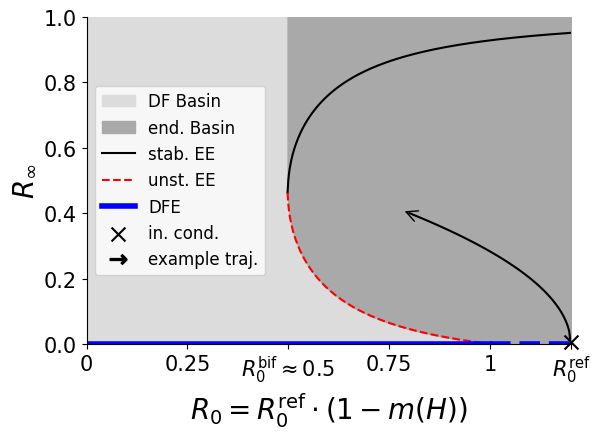

In [33]:
p['alpha'] = .12

def example_trajectory(x):
    return 0.4*np.sqrt((0.12-x)/(0.12-0.08))

plt.fill_betweenx(Rinf_unstEq[TheMask], 0, R0_EE[TheMask], color='gainsboro', label='DF Basin')
plt.fill_betweenx([Rinf_unstEq[0], 1], 0, np.full(2, R0_EE[0]), color='gainsboro')
plt.fill_between(R0_EE, R_inf_endEq, 1, color='darkgrey', label='end. Basin')
plt.fill_between(R0_EE, np.maximum(Rinf_unstEq,0), R_inf_endEq, color='darkgrey')

plt.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
plt.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')
PlotDFE(x_space='R0', lw=4)

adjust_x=0.002 # to put arrow head on top of line
adjust_y=0.001
plt.annotate("",
             xy=(0.78+adjust_x, 0.41-adjust_y),   # arrow head (left end)
             xytext=(0.8+adjust_x, 0.4-adjust_y),  # start (right end)
             arrowprops=dict(arrowstyle="->", color='k'))
plt.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', s=100, label=r'in. cond.', clip_on=False)
plt.plot(np.linspace(0.8,1.2,100), example_trajectory(np.linspace(0.08,0.12,100)), ls='-', c='k') #, label='example traj.')

plt.ylabel(rf'$R_\infty$')
plt.xlabel(r'$R_0 = R_0^{\rm ref} \cdot (1-m(H))$')
#plt.title(rf'Basins of endemic FPs and mitigation lim. cycles for $\kappa$=1')
plt.xlim(0,1.2)
plt.ylim(0,1)
plt.xticks([0,.25,R0_bif,.75,1,p['alpha']/p['gamma']],labels=[0,.25,r'$R_0^{\rm bif}\approx 0.5$',.75,1, r'$R_0^{\rm ref}$'])

ax = plt.gca()   # get current axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(ax.get_xticks()[0], ax.get_xticks()[-1])
ax.set_ylim(ax.get_yticks()[0], ax.get_yticks()[-1])

import matplotlib.lines as mlines
arrow_handle = mlines.Line2D([], [], color='k', marker=r'$\rightarrow$',
                             linestyle='None', markersize=12,
                             label='example traj.')
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(arrow_handle)
labels.append('example traj.')
plt.legend(handles, labels, loc='center left')
plt.tight_layout()
plt.savefig('img/SIRSm_BasinsAndTipping_FPvsLimCycles.pdf', bbox_inches='tight')
plt.show()

at mmax= 1 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 0.9448275862068967 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 0.9724137931034484 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 1.0 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.


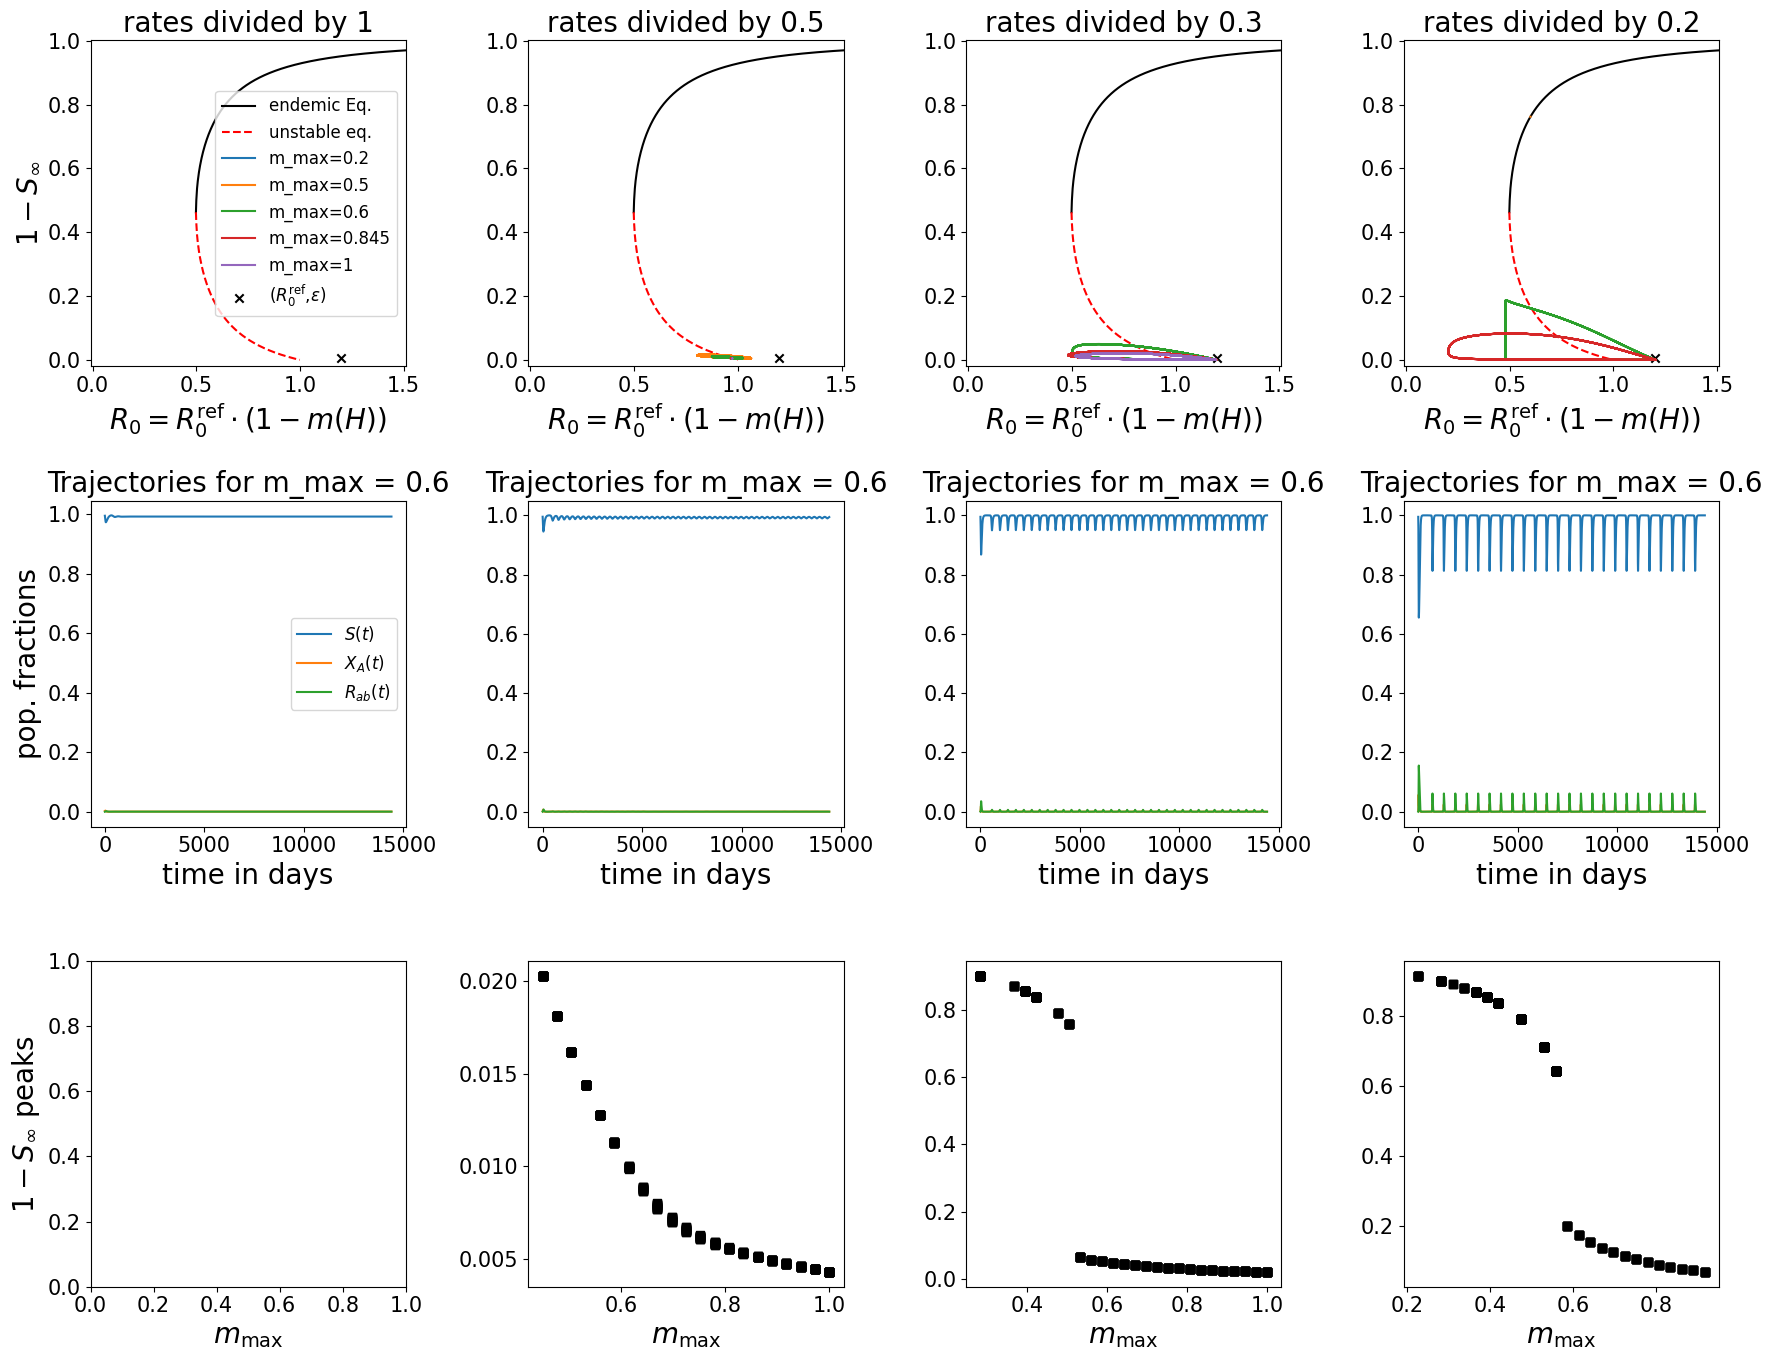

In [30]:
fraction = [1,.5,.3,.2]
mmax_values = [.2,.5,.6,.845,1]

SetInCondfullSIRS(epsi, p, InInfComp)

fig, axes = plt.subplots(3, 4, figsize=(18, 14))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k]
    mmax = .6
    p['mmax'] = mmax
    p['tmax'] = 40*360
    cut = int(p['tmax']/p['stepsize']*7/10)  # cut out relaxation into limit cycles
    
    try:
        m = model(**p)
        times, Data = m.run()
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
        
        ax1 = axes[1, k] 
        ax1.plot(times, S, label=r'$S(t)$')
        ax1.plot(times, A+AB+Ab, label=r'$X_A(t)$')
        ax1.plot(times, ab, label=r'$R_{ab}(t)$')
        #plt.plot(times,Q, label=rf'Q')
        #plt.plot(times,A, label=rf'A')
        #plt.plot(times,AB, label=rf'AB')
        #plt.plot(times,X,label='X')
        ax1.set_xlabel(r'time in days')
        ax1.set_title(rf'Trajectories for m_max = {mmax}')
        if(k==0): ax1.legend()
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
        pass
    
    ###################################################
    
    # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax

    ax2 = axes[0, k]

    ax2.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='endemic Eq.')
    ax2.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unstable eq.')
    
    for mmax in mmax_values:
        try:
            p['mmax'] = mmax
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax * m.m_normalized(H)
            
            ax2.plot(p['alpha'] * SoftPlus*SF/p['gamma'], 1 - S, label=rf'm_max={mmax}')
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
    
    ax2.set_xlim(-.01,1.5+.01)
    ax2.set_ylim(-.02,max(R_inf_endEq)+.02)
    ax2.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax2.set_xlabel(r'$R_0= R_0^{\rm ref} \cdot (1-m(H))$')
    if(k==0): ax2.legend()
    ax2.set_title(rf'rates divided by {fraction[k]}')

    ###########################################################

    ax3 = axes[2, k]

    for mmax in np.linspace(min(mmax_values),max(mmax_values),30):
        try:
            p['mmax'] = mmax
            m = model(**p)
            times, Data = m.run()
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            peak_idces, _ = scp.signal.find_peaks(1-S)
            for idx in peak_idces: ax3.scatter(mmax, 1-S[idx], marker=',', c='k')
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
        
        ax3.set_xlabel(r'$m_{\rm max}$')
    
    if(k==0):
        ax2.set_ylabel(r'$1-S_\infty$')
        ax1.set_ylabel(r'pop. fractions')
        ax3.set_ylabel(r'$1-S_\infty$ peaks')
        
plt.tight_layout()
#plt.savefig('img/SIRSm_LimitCyclesInMitig_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

# p['gamma'] = np.full(2,.1)
# p['alpha'] = alpha_crit
# p['beta'] = np.full(2,C*alpha_crit)
# p['nu'] = np.full(2,.01)

at mmax= 1.0 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.


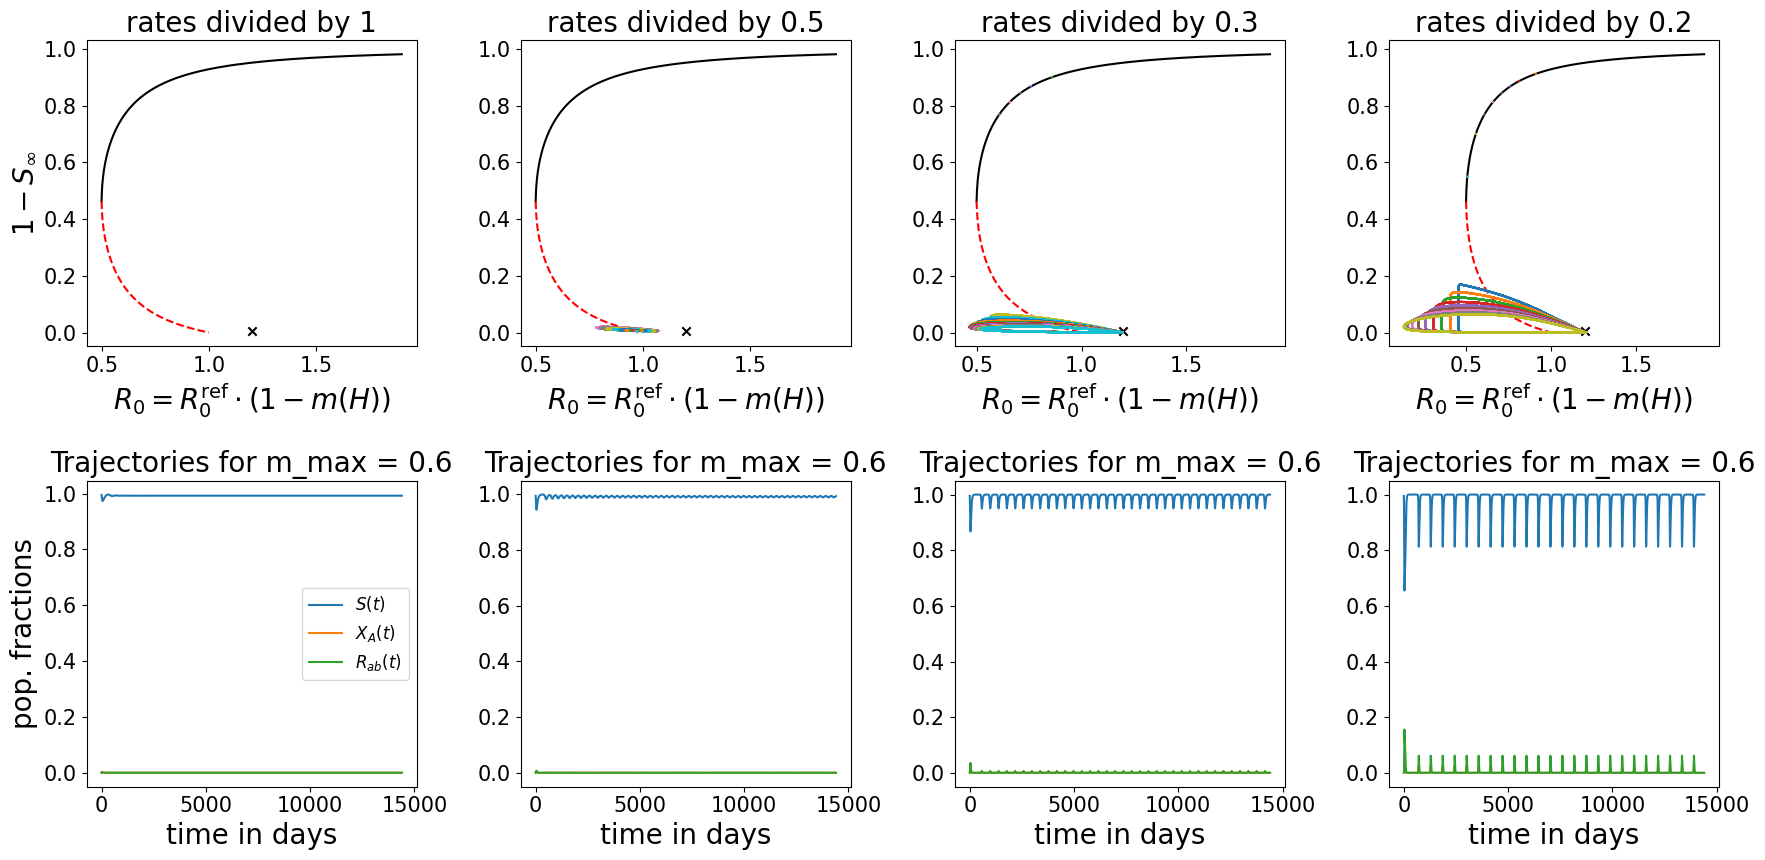

In [31]:
fraction = [1,.5,.3,.2]
mmax_values = np.linspace(.2,1,20)

SetInCondfullSIRS(epsi, p, InInfComp)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k]
    mmax = .6
    p['mmax'] = mmax
    p['tmax'] = 40*360 
    cut = int(p['tmax']/p['stepsize']*7/10)  # cut out relaxation into limit cycles
    
    try:
        m = model(**p)
        times, Data = m.run()
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
        
        ax1 = axes[1, k] 
        ax1.plot(times, S, label=r'$S(t)$')
        ax1.plot(times, A+AB+Ab, label=r'$X_A(t)$')
        ax1.plot(times, ab, label=r'$R_{ab}(t)$')
        #plt.plot(times,Q, label=rf'Q')
        #plt.plot(times,A, label=rf'A')
        #plt.plot(times,AB, label=rf'AB')
        #plt.plot(times,X,label='X')
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
        pass

    ax1.set_xlabel(r'time in days')
    ax1.set_title(rf'Trajectories for m_max = {mmax}')
    if(k==0): ax1.legend()
    
    ###################################################
    
    # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax

    ax2 = axes[0, k]

    ax2.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='endemic Eq.')
    ax2.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unstable eq.')    
    
    for mmax in mmax_values:
        try:
            p['mmax'] = mmax
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax * m.m_normalized(H)
            
            ax2.plot(p['alpha'] * SoftPlus*SF/p['gamma'], 1 - S, label=rf'm_max={mmax}')
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
    
    ax2.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax2.set_xlabel(r'$R_0= R_0^{\rm ref} \cdot (1-m(H))$')
    if(k==0): 
        ax2.set_ylabel(r'$1-S_\infty$')
        ax1.set_ylabel(r'pop. fractions')
    ax2.set_title(rf'rates divided by {fraction[k]}')

plt.tight_layout()
plt.show()

# p['gamma'] = np.full(2,.1)
# p['alpha'] = alpha_crit
# p['beta'] = np.full(2,C*alpha_crit)
# p['nu'] = np.full(2,.01)

In [73]:
mmax_valueList = [
    [0.3, 0.32, 0.34, 0.36, 0.38, 0.4],
    [0.4, 0.42, 0.44, 0.46, 0.48, 0.5],
    [0.5, 0.52, 0.54, 0.56, 0.58, 0.6],
    [0.6, 0.64, 0.68, 0.72, 0.76, 0.8]
]

SetInCondfullSIRS(epsi, p, InInfComp)
p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
cut = int(p['tmax']/p['stepsize']*7/10)

fraction = [2,.5,.3,.2]

Rinf = np.zeros((len(mmax_valueList),len(fraction),len(mmax_valueList[0]),2,int(p['tmax']/p['stepsize']-cut)))

for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
    for k in range(len(fraction)):
        
        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] 
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k]
        
        # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax
        
        for mmax_idx in range(len(mmax_values)):
            try: 
                p['mmax'] = mmax_values[mmax_idx]
                m = model(**p)
                times, Data = m.run()
                times = times[cut:]
                S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
                SF = m.seasonalforcing(times)
                SoftPlus = 1 - mmax_values[mmax_idx] * m.m_normalized(H)
                FOI = p['alpha'] * SoftPlus*SF

                if(len(FOI)>0):
                    Rinf[mmax_val_idx,k,mmax_idx,0,:] = FOI
                    Rinf[mmax_val_idx,k,mmax_idx,1,:] = 1-S
            except RuntimeError as errormessage:
                Rinf[mmax_val_idx,k,mmax_idx,0,:] = -1
                Rinf[mmax_val_idx,k,mmax_idx,1,:] = -1
                print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
                pass
            


np.save('Data/DataSIRSm_BLOCK_LimCycles_FOI_vs_1-S_fordiff_Ratefractions_mmax.npy', Rinf)

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_27000\2603316291.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


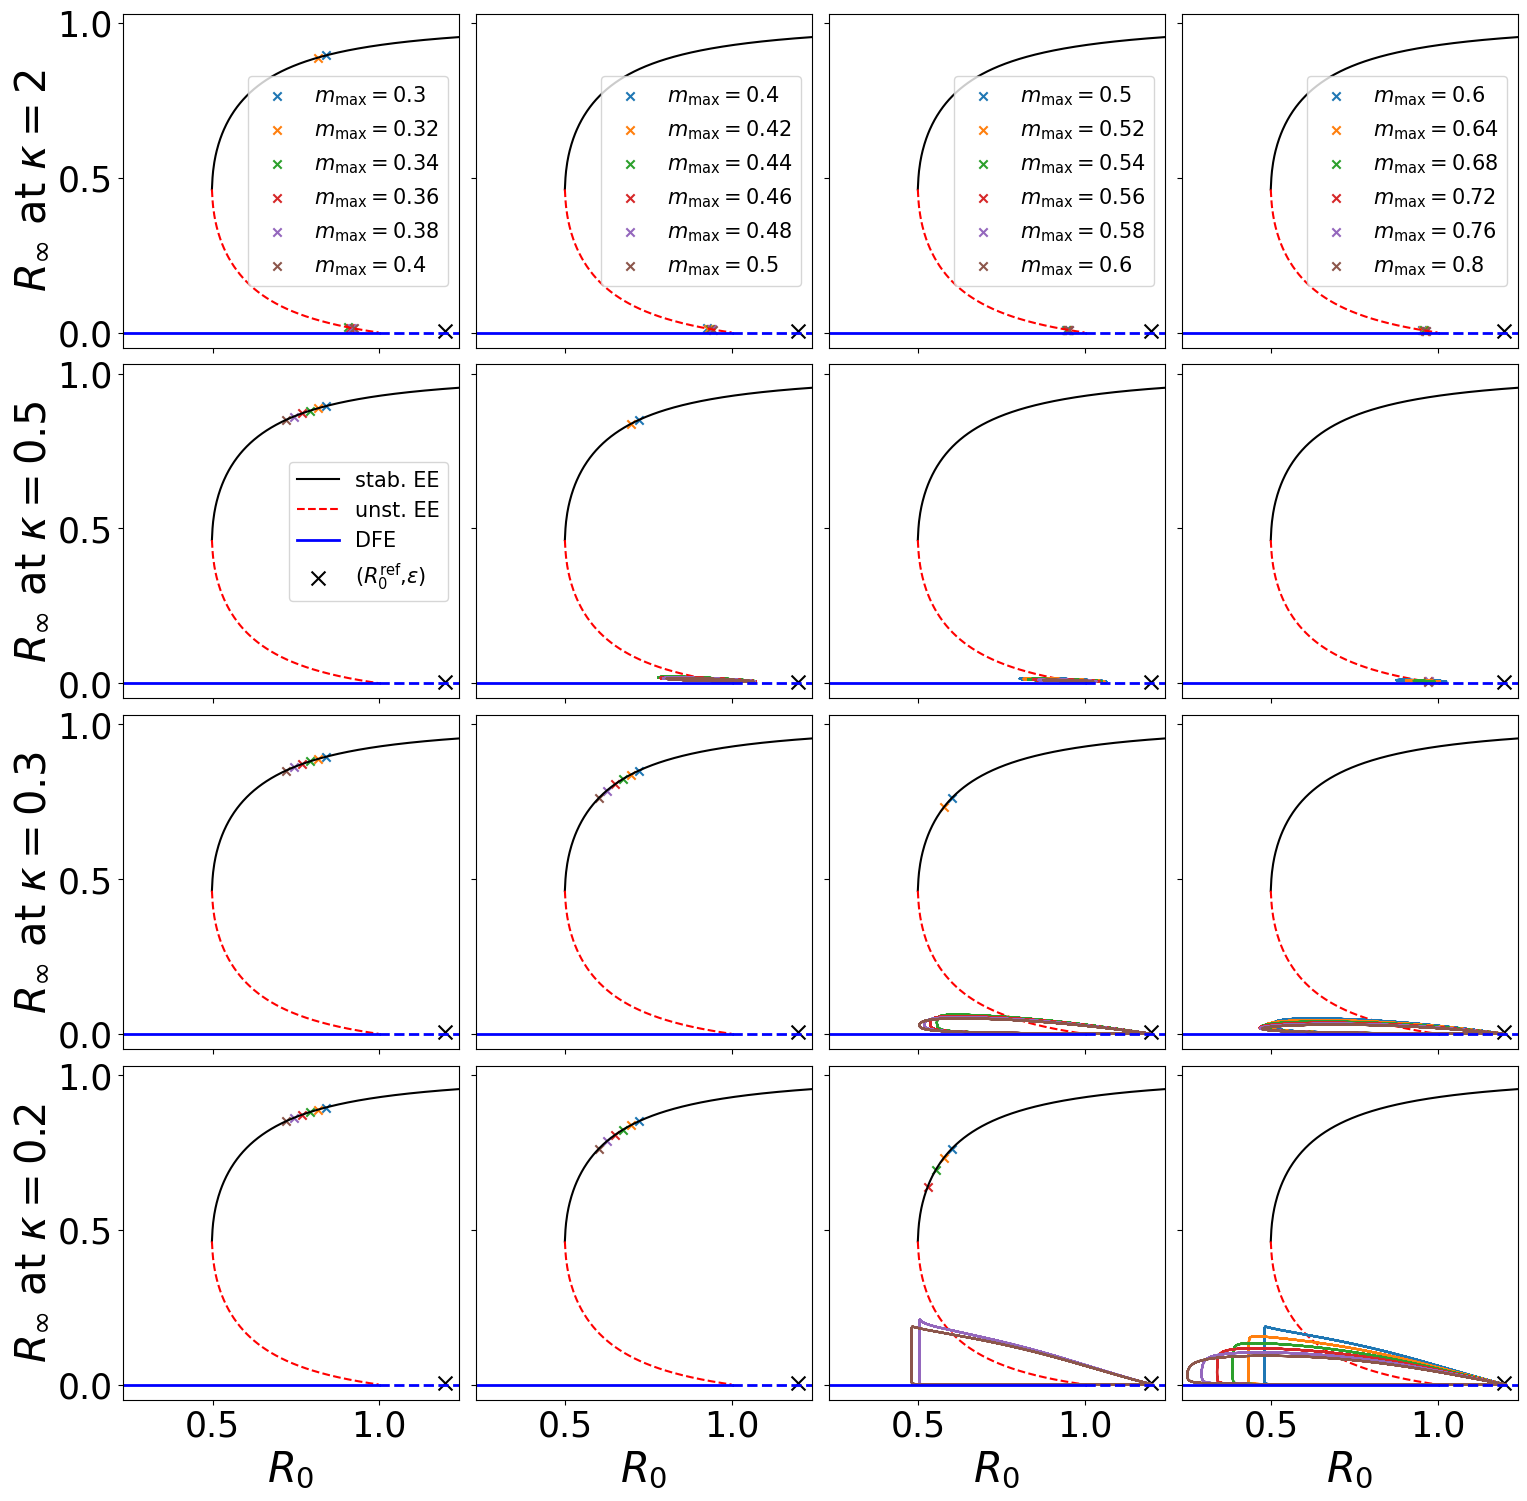

In [60]:
mmax_valueList = [
    [0.3, 0.32, 0.34, 0.36, 0.38, 0.4],
    [0.4, 0.42, 0.44, 0.46, 0.48, 0.5],
    [0.5, 0.52, 0.54, 0.56, 0.58, 0.6],
    [0.6, 0.64, 0.68, 0.72, 0.76, 0.8]
]
COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(mmax_valueList[0])]

fraction = [2,.5,.3,.2]

Rinf = np.load('Data/DataSIRSm_BLOCK_LimCycles_FOI_vs_1-S_fordiff_Ratefractions_mmax.npy')

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 25

fig, axes = plt.subplots(4, 4, figsize=(18, 18), gridspec_kw={'wspace':0.05, 'hspace':0.05})

for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
    for k in range(len(fraction)):

        p['alpha'] = .12/fraction[k]
        p['gamma'] = .1/fraction[k]
        R0_ref = p['alpha']/p['gamma']
        
        ax = axes[k, mmax_val_idx]

        ax.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE' if mmax_val_idx==0 and k==1 else None)
        ax.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE' if mmax_val_idx==0 and k==1 else None)   
        
        for mmax_idx in range(len(mmax_values)):
            FOI = Rinf[mmax_val_idx,k,mmax_idx,0,:]
            if(FOI[0] == -1): continue # bcs if its -1 then the solver stopped due to error
            if(FOI[0] != 0): # bcs if its 0 then the solver stopped and the value of FOI and Rinf stayed as initialized at 0
                Rinf_values = Rinf[mmax_val_idx,k,mmax_idx,1,:]
            if(max(FOI)-min(FOI) < 0.01 and max(Rinf_values)-min(Rinf_values) < 0.01):
                ax.scatter(FOI[0]/p['gamma'], Rinf_values[0], marker='x', label=r'$m_{\rm max}=$'+f'{mmax_values[mmax_idx]}' if k==0 else None, c=COL[mmax_idx])
            else: ax.plot(FOI/p['gamma'], Rinf_values, label=r'$m_{\rm max}=$'+f'{mmax_values[mmax_idx]}' if k==0 else None, c=COL[mmax_idx])

        if(mmax_val_idx==0): ax.set_ylabel(rf'$R_\infty$ at $\kappa=${fraction[k]}')
        else: ax.tick_params(labelleft=False)
        if(k==0): ax.legend()
        
        PlotDFE(ax,x_space='R0',lw=2)
        ax.set_xlim(-.01,R0_EE[-1])
        # ax.set_ylim(-.02,max(R_inf_endEq)+.02)
        ax.scatter(R0_ref, epsi, marker='x', c='k', s=100, label=r'($R_0^{\rm ref}$,$\epsilon$)')
        if(k==3): ax.set_xlabel(r'$R_0$') #= R_0^{\rm ref} \cdot (1-m(H))$')
        else: ax.tick_params(labelbottom=False)
        #if(mmax_val_idx==0): ax.set_title(rf'rates divided by {fraction[k]}')
        if(k==1 and mmax_val_idx==0): ax.legend()
        ax.set_xlim(0.23,1.24)

plt.tight_layout()
plt.savefig('img/SIRSm_BLOCK_LimCycles_FOI_vs_1-S_fordiff_Ratefractions_mmax.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

### Heatmap: Regions and Maxima of 1-S for diff mmax vs Ratefraction

In [61]:
Years_evol = 100
########### AC or decay rate METHOD ###########
# decay rate method
MethodLabel = "_checkedwithAmplDecay"

# # AC Method
# MethodLabel = ""

########### Plotting range ##############
# # original
# AddedLabel = ""
# Vmax = .06
# mmax = np.linspace(.5,1,40)
# fraction = np.linspace(.1,.5,20)

#extended_logspace
AddedLabel = "_extended_logspace"
Vmax = 1
mmax = np.logspace(-1,0,40)
fraction = np.logspace(-0.64,np.log10(3),20) # starting with frac=kappa=.13 > 0.12 = alpha, to mantain rates below 1. Else: populations go below 0 in simulation.

# #extended
# AddedLabel = "_extended"
# Vmax = 1
# mmax = np.linspace(.1,1,40)
# fraction = np.linspace(10**-0.64,3,20) # starting with frac=kappa=.13 > 0.12 = alpha, to mantain rates below 1. Else: populations go below 0 in simulation.

In [169]:
if(MethodLabel == ""):
    Peaks = np.empty((len(mmax),len(fraction),2)) # FOR CASE WITH AUTOCORRELATIONS: # last "2" is [PeakValue, Type] to know whether its a limit cycle (Type=1), FP (Type=0) or chaotic (Type=2)
elif(MethodLabel == "_checkedwithAmplDecay"):
    Peaks = np.empty((len(mmax),len(fraction),3)) # FOR CASE WITH AMPLITUDE DECAY: last "3" is [PeakValue, PeriodicityValueFOI, PeriodicityValueRinf] to know whether its a limit cycle or FP etc

SetInCondfullSIRS(epsi, p, InInfComp)

for mmax_idx in range(len(mmax)):
    for k in range(len(fraction)):

        # if(mmax[mmax_idx]<0.7): Years_evol = 25 # here yellow FPs which converge fast
        # else: Years_evol = 100 
        
        Years_evol = 100

        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] 
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k] 
        p['tmax'] = Years_evol*360 
        cut = int(p['tmax']/p['stepsize']*7/10)

        p['tolerances'] = [1e-15, 1e-18]
        
        p['mmax'] = mmax[mmax_idx]
        m = model(**p)

        try:
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax[mmax_idx] * m.m_normalized(H)
            FOI = p['alpha'] * SoftPlus*SF

            if(MethodLabel == ""):
                ######## CHECK WITH AUTOCORRELATIONS (Problem: LC and slowly conv FPs undistinguishable) ##########
                #if(np.max(FOI)-np.min(FOI)<.015 or np.max(1-S)-np.min(1-S)<.002): # Fixpoint
                if(is_Fixpoint(FOI) or is_Fixpoint(1-S)): 
                    Peaks[mmax_idx, k, 0] = np.max(1-S) #np.max([1-S[idx] for idx in peak_idces])
                    Peaks[mmax_idx, k, 1] = 0
                    continue
                else: #if(max(1-S)-min(1-S)>.01):

                    # # check if chaotic 1:
                    # found_NotPeriodic = False
                    # FOI_middlevalue = np.mean((np.max(FOI),np.min(FOI)))

                    # counter = 0
                    # for i in range(len(FOI)-1):
                    #     if(FOI[i]<FOI_middlevalue and FOI[i+1]>=FOI_middlevalue):
                    #         if(counter==0): 
                    #             upper_ref = 1-S[i]
                    #             counter += 1
                    #         if(counter==1): 
                    #             lower_ref = 1-S[i]
                    #             counter += 1
                    #         if(counter==2 and upper_ref-(1-S[i])>0.001 and 1-S[i]-lower_ref>0.001): # chaotic
                    #             found_NotPeriodic = True
                    #             break

                    # # check if chaotic 2:
                    # import nolds
                    # LE = nolds.lyap_r(1-S)
                    # if(LE>0): # chaotic
                    #     found_NotPeriodic = True

                    #check if chaotic 3:
                    if(CheckIfPeriodic(FOI) and CheckIfPeriodic(1-S)):
                        found_NotPeriodic = False
                    else:
                        found_NotPeriodic = True

                            
                    if(found_NotPeriodic): # not periodic
                        Peaks[mmax_idx, k, 0] = np.max(1-S) #np.max([1-S[idx] for idx in peak_idces])
                        Peaks[mmax_idx, k, 1] = 2
                        continue
                    else: # limit cycle
                        Peaks[mmax_idx, k, 0] = np.max(1-S) #np.max([1-S[idx] for idx in peak_idces])
                        Peaks[mmax_idx, k, 1] = 1

            elif(MethodLabel == "_checkedwithAmplDecay"):
                ################ CHECK WITH PEAK AMPLITUDE DECAY  ###################
                if(is_Fixpoint(1-S, checkOnlyLastValues=True) == True): # check if FP first
                    Peaks[mmax_idx, k, 0] = np.max(1-S)
                    Peaks[mmax_idx, k, 1] = -100
                    Peaks[mmax_idx, k, 2] = -100
                else:
                    Peaks[mmax_idx, k, 0] = np.max(1-S)
                    Peaks[mmax_idx, k, 1] = amplitude_decay(FOI)
                    Peaks[mmax_idx, k, 2] = amplitude_decay(1-S)

        except RuntimeError as errormessage:
            print(errormessage)
            Peaks[mmax_idx, k, 0] = -1
            Peaks[mmax_idx, k, 1] = -1
            pass

    print(mmax_idx+1, "/", len(mmax))
p['tolerances'] = [1e-10, 1e-13]

np.save(f'Data/DataSIRSm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy', Peaks)

C:\Users\Rodrigo Amaral Lind\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


1 / 40
2 / 40
3 / 40
4 / 40
5 / 40
6 / 40
7 / 40
8 / 40
9 / 40
10 / 40
11 / 40
12 / 40
13 / 40
14 / 40
15 / 40
Need 10 peaks for amplitude decay fit, found only 4
16 / 40
17 / 40
18 / 40
19 / 40
20 / 40
21 / 40
Need 10 peaks for amplitude decay fit, found only 9
22 / 40
23 / 40
24 / 40
25 / 40
26 / 40
27 / 40
28 / 40
29 / 40
30 / 40
31 / 40
32 / 40
33 / 40
34 / 40
35 / 40
36 / 40
37 / 40
38 / 40
39 / 40
40 / 40


In [ ]:
def PlotSIRSm_HeatmapOfLimCycleMean_mmax_vs_fraction(AddedLabel, MethodLabel, AmplDec_thresh = 1e-5): # change AmplDec_thresh for appropriate visualization when using Amplitude decay method
    Peaks = np.load(f"Data/DataSIRSm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy")

    plt.rcParams['font.size'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 18
    plt.rcParams['axes.titlesize'] = 30

    ax = plt.gca()
    LC_marker = 'o'

    for mmax_idx in range(len(mmax)):
        for k in range(len(fraction)):
            if(MethodLabel == ""):
                # FOR CASE WITH AUTOCORRELATIONS:
                if(Peaks[mmax_idx,k,1] == -1): ax.scatter(mmax[mmax_idx],fraction[k],c='k',marker='x',s=65) # ERROR
                elif(Peaks[mmax_idx,k,1] == 1): use_marker = LC_marker # its a limit cycle
                elif(Peaks[mmax_idx,k,1] == 0): use_marker = '$F$' # its a fixpoint
                elif(Peaks[mmax_idx,k,1] == 2): use_marker = '$o$' #'$C$' # its not periodic
                else: print('ERROR: invalid classification')

            elif(MethodLabel == "_checkedwithAmplDecay"):
                # FOR CASE WITH AMPLITUDE DECAY:
                AmplDec_FOI = Peaks[mmax_idx, k, 1]
                AmplDec_Rinf = Peaks[mmax_idx, k, 2]

                if(AmplDec_FOI == -100 or AmplDec_Rinf == -100): use_marker = '$F$' # its a fixpoint
                elif(np.abs(AmplDec_FOI) < AmplDec_thresh or np.abs(AmplDec_Rinf) < AmplDec_thresh): use_marker = LC_marker # its a limit cycle
                elif(AmplDec_FOI < -AmplDec_thresh and AmplDec_Rinf < -AmplDec_thresh): use_marker = '.' # infinitesimal limit cycles (looks like slowly converging fixpoint)
                elif(AmplDec_FOI > AmplDec_thresh or AmplDec_Rinf > AmplDec_thresh): use_marker = '$D$' # diverging
                else: use_marker = '$?$' # inconclusive

                if(use_marker=='$?$' or use_marker=='$D$'): use_marker = '$F$' # treat inconclusive and diverging as fixpoints for plotting purposes (checked individually)
                if(use_marker=='$F$' and Peaks[mmax_idx,k,0]<.6): use_marker='.' # treat low prevalence fixed points as infinitesimal limit cycles for plotting purposes (checked individually)
                
            if(Peaks[mmax_idx,k,0] == 0): ax.scatter(mmax[mmax_idx],fraction[k],c='k',marker=use_marker,s=65)
            else: cax = ax.scatter(mmax[mmax_idx],fraction[k],c=Peaks[mmax_idx,k,0],cmap='spring',vmin=0,vmax=Vmax,marker=use_marker,s=65)
    
    ax.set_xlabel(r'$m_{\rm max}$')
    ax.set_ylabel(r'$\kappa$')
    if(AddedLabel == "_extended_logspace"): 
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xticks([.1,.2,.3,.5,.7,1],labels=[.1,.2,.3,.5,.7,1])
        ax.set_yticks([.3,.5,1,2,3],labels=[.3,.5,1,2,3])
    plt.colorbar(cax, label=r'max$(1-S_\infty)$')

    plt.rcParams['font.size'] = 20
    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['axes.titlesize'] = 20


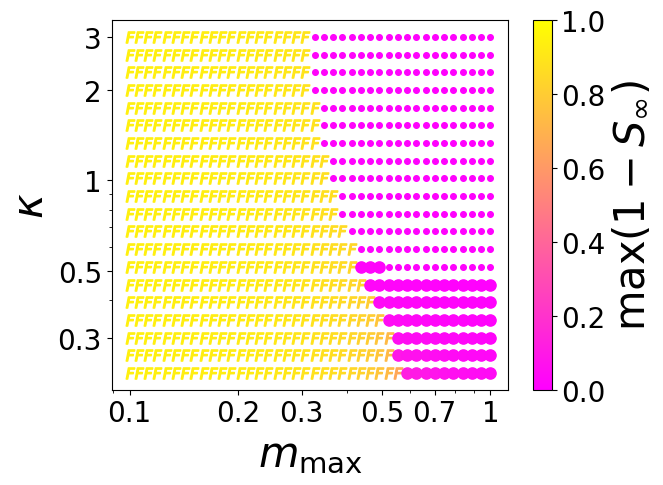

In [71]:
PlotSIRSm_HeatmapOfLimCycleMean_mmax_vs_fraction(AddedLabel, MethodLabel)

plt.savefig(f'img/SIRSm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.pdf', bbox_inches='tight')
#plt.legend()
plt.show()

mmax= 1.0 fraction= 0.5161490508726974 1-S= [ 0.00431509 -0.08263474 -0.02809713]
This one was slowly converging to a fixpoint


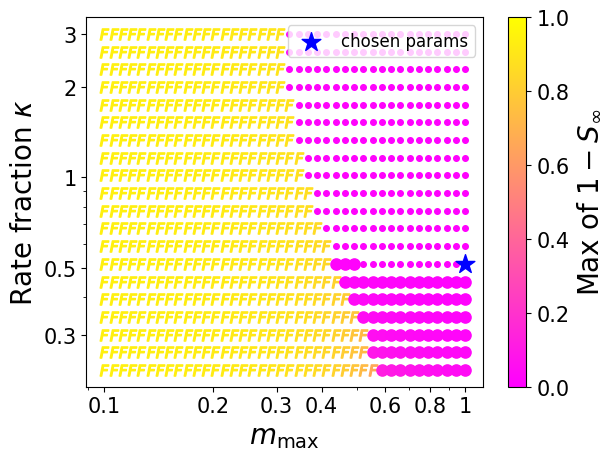

C:\Users\Rodrigo Amaral Lind\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[0.005      0.00511636 0.00523308 ... 0.00431509 0.00431509 0.00431509]
[0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509
 0.00431509 0.00431509 0.00431509 0.00431509 0.00431509 0

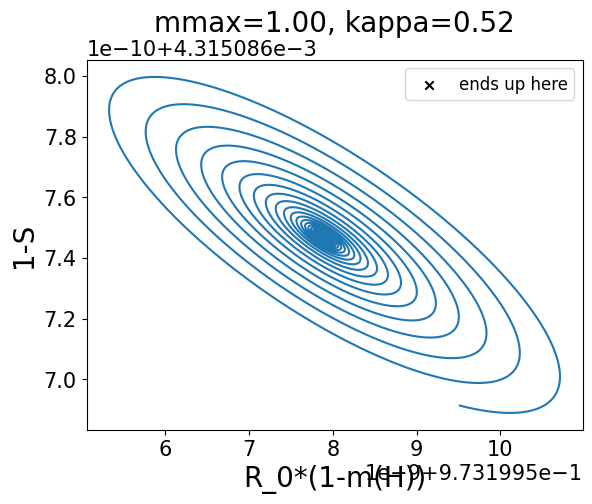

Amplitude decay in FOI -0.08263473542910588 % in Rinf: -0.02809712653436524 %


In [ ]:
# check trajectories:

# For AB(0) case:
#extended: real Lim Cycle mmax=22, k=2. They go as small as dFOI=.02, dR=.0025
# slowly conv FPS after 100yrs still dFOI=0.01, dR=0.0015

mmax_idx = -1 # For AB(0) case: For extended & k=9: 15 FP(direct), 20 FP(osc), in between VERY SLOWLY CONV FPS (appeared to be lim cycles first)
k = 6
Years_evol = 100 # shrink to 60-100 if alpha=0.09 (init at tipp point), else if alpha=0.12 can do 1000

# For AB(0) case: chaotic 4,4 or 5,5 ### 4loops k=5,mmax=1 ### 1loop k=6,mmax=1 (frühere indices also alles jetzt doppelt)

Peaks = np.load(f"Data/DataSIRSm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy")

print('mmax=',mmax[mmax_idx],'fraction=',fraction[k],'1-S=',Peaks[mmax_idx,k])


if(MethodLabel == ""):
    # FOR CASE WITH AUTOCORRELATIONS:
    if(Peaks[mmax_idx,k,1] == -1): print('This one gave error')
    elif(Peaks[mmax_idx,k,1] == 1): print('This one was classified as a limit cycle')
    elif(Peaks[mmax_idx,k,1] == 0): print('This one was classified as a fixpoint')
    elif(Peaks[mmax_idx,k,1] == 2): print('This one was classified as not periodic')
    else: print('ERROR: invalid classification')

elif(MethodLabel == "_checkedwithAmplDecay"):
    # FOR CASE WITH AMPLITUDE DECAY:
    AmplDec_thresh = 1e-5 ## chenge this for appropriate visualization
    AmplDec_FOI = Peaks[mmax_idx, k, 1]
    AmplDec_Rinf = Peaks[mmax_idx, k, 2]

    if(AmplDec_FOI == -100 or AmplDec_Rinf == -100): print('This one was classified as a fixpoint')
    elif(np.abs(AmplDec_FOI) < AmplDec_thresh or np.abs(AmplDec_Rinf) < AmplDec_thresh): print('This one was classified as a limit cycle')
    elif(AmplDec_FOI < -AmplDec_thresh and AmplDec_Rinf < -AmplDec_thresh): print('This one was slowly converging to a fixpoint')
    elif(AmplDec_FOI > AmplDec_thresh or AmplDec_Rinf > AmplDec_thresh): print('This one was diverging')
    else: print('This one was inconclusive in classification')

##############################################
PlotSIRSm_HeatmapOfLimCycleMean_mmax_vs_fraction(AddedLabel, MethodLabel)
plt.scatter(mmax[mmax_idx],fraction[k],c='b',marker='*',s=200,label='chosen params')
plt.legend()
plt.show()
#######

#SetTolerances_for_kappa_mmax(fraction[k], mmax[mmax_idx], p)
p['tolerances'] = [1e-15, 1e-18] # set tolerances always lower

SetInCondfullSIRS(epsi, p, InInfComp)

p['gamma'] = .1/fraction[k]
p['alpha'] = .12/fraction[k] 
p['nu'] = .01/fraction[k]
p['beta'] = C*p['alpha'] 
p['tmax'] = Years_evol*360 
cut = int(p['tmax']/p['stepsize']*7/10)
p['mmax'] = mmax[mmax_idx]


m = model(**p)
times, Data = m.run()

# UNCUT PLOTS
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
SoftPlus_uncut = 1 - mmax[mmax_idx] * m.m_normalized(H)

print(1-S)

# plt.title('1-m(h)')
# plt.plot(times/360, SoftPlus_uncut)
# plt.xlabel('time in years')
# plt.xticks(rotation=45)
# plt.show()
# # print('softplus shape=',SoftPlus.shape,'\ncut=', cut)



# plt.title('H in [0,1]')
# plt.plot(times/360, H,label='H')
# plt.xlabel('time in years')
# plt.xticks(rotation=45)
# plt.legend()
# plt.show()
# # print('times shape=',times.shape)
# # print('S shape=',S.shape)
# # print('tmax/timestep=',p['tmax']/p['stepsize'])

# CUT PLOTS
times = times[cut:]
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
SF = m.seasonalforcing(times)
SoftPlus = 1 - mmax[mmax_idx] * m.m_normalized(H)
FOI = p['alpha'] * SoftPlus*SF

print(1-S[-100:])
print('=> is_Fixpoint=',is_Fixpoint(1-S, checkOnlyLastValues=True))

plt.plot(FOI/p['gamma'], 1-S)
plt.scatter(FOI[-1]/p['gamma'],1-S[-1],label='ends up here',marker='x',c='k')
plt.title(f'mmax={mmax[mmax_idx]:.2f}, kappa={fraction[k]:.2f}')
plt.xlabel(r'$R_0(1-m(H))$')
plt.ylabel('1-S')
plt.legend()
plt.show()

if(MethodLabel == "_checkedwithAmplDecay"):
    print('Amplitude decay in FOI', amplitude_decay(FOI), '% in Rinf:', amplitude_decay(1-S), '%')

# plt.plot(FOI_ac, label='FOI ac')
# plt.legend()
# plt.show()

# plt.plot(Rinf_ac, label='Rinf ac')
# plt.legend()
# plt.show()

# numeric errors at 65000 days for frac .3105. at 10000 for frac 0.2895. at

p['tolerances'] = [1e-10, 1e-13]

Amplitude decay in R0 -0.00017810376945708403 % in Ainf: -0.44889772493916275 % in Rinf: -0.019783754604743183 %


(0.00037635511909388155, 0.0003763553013506531)

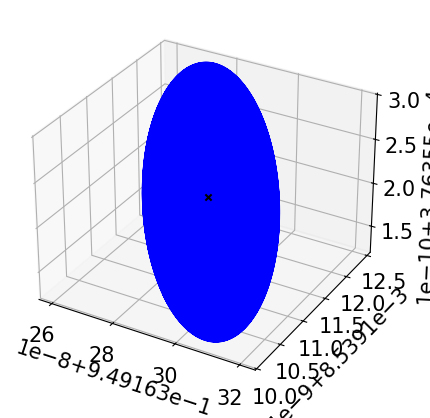

In [ ]:
# SLOW CONVERGING FP Example: FEEDBACKLOOP AROUND BASIN BOARDER

R0, Rinf, Ainf = np.load('Data/DataSIRSm_RapidFeedbackloopExample_R0_Rinf_Ainf_10kYrs_downsampleBy10.npy')

print('Amplitude decay in R0', amplitude_decay(R0), '% in Ainf:', amplitude_decay(Ainf),'% in Rinf:', amplitude_decay(Rinf),'%')

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')

ax.plot(R0, Rinf, Ainf, label='trajectory', c='b',lw=.5) 
ax.plot(R0_EE, R_inf_endEq, Ainf_endEq, ls='-', c='k') #, label='stab. EE')
ax.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], Ainf_unstEq[TheMask], ls='-', c='r') #, label='unst. EE.')
ax.scatter(R0[-1],Rinf[-1],Ainf[-1],label='ends up here',marker='x',c='k')

# Zoomin
RangeFaktor = 8015.5 # zoom to see unstable EE (gerade so)
RangeFaktor = 0 # Zoom to see trajectory detail

ax.set_xlim((np.min(R0)-RangeFaktor*(np.max(R0)-np.min(R0)),np.max(R0)+RangeFaktor*(np.max(R0)-np.min(R0))))
ax.set_ylim((np.min(Rinf)-RangeFaktor*(np.max(Rinf)-np.min(Rinf)),np.max(Rinf)+RangeFaktor*(np.max(Rinf)-np.min(Rinf))))
ax.set_zlim((np.min(Ainf)-RangeFaktor*(np.max(Ainf)-np.min(Ainf)),np.max(Ainf)+RangeFaktor*(np.max(Ainf)-np.min(Ainf))))

### Heatmap For Paper

In [5]:
Years_evol = 100
########### AC or decay rate METHOD ###########
# decay rate method
MethodLabel = "_checkedwithAmplDecay"

# # AC Method
# MethodLabel = ""

########### Plotting range ##############

#more extended logspace in kappa + save mean NOT max
AddedLabel = "_ForPaper"
Vmax = 1
mmax = np.logspace(-1,0,40)
fraction = np.logspace(-0.7,np.log10(3),20) # starting with frac=kappa=.13 > 0.12 = alpha, to mantain rates below 1. Else: populations go below 0 in simulation.

################## Colormap #######################
# SEBA SAYS THIS ONE IS NOT GOOD FOR BLIND PEOPLE 
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
cm_spring = cm.get_cmap("spring")
Val1 = 0.158
Val2 = 0.908
ColStep = (Val2-Val1)/5
colors = [
    (0.0, 'k'), (0.001, 'k'), (0.001, cm_spring(0)), (Val1, cm_spring(0)),
    (Val1, 'grey'), (Val1+ColStep, 'grey'), (Val1+ColStep, 'grey'), (Val1+ColStep*2, 'grey'), 
    (Val1+ColStep*2, 'darkorange'), (Val1+ColStep*3, 'darkorange'), (Val1+ColStep*3, 'gold'), (Val1+ColStep*4, 'gold'), 
    (Val1+ColStep*4, 'yellow'), (Val2, 'yellow'), (Val2, 'yellow'), (1, 'yellow')
] # changed last colors from orange/gold/yellow to gold/yellow/yellow (see 'Non matching Heatmap' chapter in Symmetric Model +sm.ipynb)
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# # COLORBLIND FRIENDLY VERSION (BUT UGLY COLORS)
# from matplotlib.colors import LinearSegmentedColormap
# Col1 = '#70362D'
# Col2 = '#8D475B'
# Col3 = 'grey'#'#916690'
# Col4 = 'grey'#'#728DBB'
# Col5 = '#2EB3CB'
# Col6 = '#15D5B8'
# Col7 = '#80EF8F'
# Col8 = '#E6FE67'
# Val1 = 0.133
# Val2 = 0.908
# ColStep = (Val2-Val1)/6
# colors = [
#     (0.0, 'k'), (0.001, 'k'), (0.001, Col1), (Val1-ColStep/8, Col1),
#     (Val1-ColStep/8, Col2), (Val1+ColStep, Col2), (Val1+ColStep, Col3), (Val1+ColStep*2, Col3), 
#     (Val1+ColStep*2, Col4), (Val1+ColStep*3, Col4), (Val1+ColStep*3, Col5), (Val1+ColStep*4, Col5), 
#     (Val1+ColStep*4, Col6), (Val2-ColStep,Col7), (Val2-ColStep, Col7), (Val2, Col8), (1, Col8)
# ]
# cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

C:\Users\PCUser\AppData\Local\Temp\ipykernel_28048\2701995109.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm_spring = cm.get_cmap("spring")


In [35]:
if(MethodLabel == ""):
    Peaks = np.empty((len(mmax),len(fraction),2)) # FOR CASE WITH AUTOCORRELATIONS: # last "2" is [PeakValue, Type] to know whether its a limit cycle (Type=1), FP (Type=0) or chaotic (Type=2)
elif(MethodLabel == "_checkedwithAmplDecay"):
    Peaks = np.empty((len(mmax),len(fraction),3)) # FOR CASE WITH AMPLITUDE DECAY: last "3" is [PeakValue, PeriodicityValueFOI, PeriodicityValueRinf] to know whether its a limit cycle or FP etc

SetInCondfullSIRS(epsi, p, InInfComp)

for mmax_idx in range(len(mmax)):
    for k in range(len(fraction)):

        # if(mmax[mmax_idx]<0.7): Years_evol = 25 # here yellow FPs which converge fast
        # else: Years_evol = 100 
        
        Years_evol = 100

        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] 
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k] 
        p['tmax'] = Years_evol*360 
        cut = int(p['tmax']/p['stepsize']*7/10)

        p['tolerances'] = [1e-15, 1e-18]
        
        p['mmax'] = mmax[mmax_idx]
        m = model(**p)

        try:
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax[mmax_idx] * m.m_normalized(H)
            FOI = p['alpha'] * SoftPlus*SF

            if(MethodLabel == ""):
                ######## CHECK WITH AUTOCORRELATIONS (Problem: LC and slowly conv FPs undistinguishable) ##########
                #if(np.max(FOI)-np.min(FOI)<.015 or np.max(1-S)-np.min(1-S)<.002): # Fixpoint
                if(is_Fixpoint(FOI) or is_Fixpoint(1-S)): 
                    Peaks[mmax_idx, k, 0] = np.mean(1-S) #np.max([1-S[idx] for idx in peak_idces])
                    Peaks[mmax_idx, k, 1] = 0
                    continue
                else: #if(max(1-S)-min(1-S)>.01):

                    # # check if chaotic 1:
                    # found_NotPeriodic = False
                    # FOI_middlevalue = np.mean((np.max(FOI),np.min(FOI)))

                    # counter = 0
                    # for i in range(len(FOI)-1):
                    #     if(FOI[i]<FOI_middlevalue and FOI[i+1]>=FOI_middlevalue):
                    #         if(counter==0): 
                    #             upper_ref = 1-S[i]
                    #             counter += 1
                    #         if(counter==1): 
                    #             lower_ref = 1-S[i]
                    #             counter += 1
                    #         if(counter==2 and upper_ref-(1-S[i])>0.001 and 1-S[i]-lower_ref>0.001): # chaotic
                    #             found_NotPeriodic = True
                    #             break

                    # # check if chaotic 2:
                    # import nolds
                    # LE = nolds.lyap_r(1-S)
                    # if(LE>0): # chaotic
                    #     found_NotPeriodic = True

                    #check if chaotic 3:
                    if(CheckIfPeriodic(FOI) and CheckIfPeriodic(1-S)):
                        found_NotPeriodic = False
                    else:
                        found_NotPeriodic = True

                            
                    if(found_NotPeriodic): # not periodic
                        Peaks[mmax_idx, k, 0] = np.mean(1-S) #np.max([1-S[idx] for idx in peak_idces])
                        Peaks[mmax_idx, k, 1] = 2
                        continue
                    else: # limit cycle
                        Peaks[mmax_idx, k, 0] = np.mean(1-S) #np.max([1-S[idx] for idx in peak_idces])
                        Peaks[mmax_idx, k, 1] = 1

            elif(MethodLabel == "_checkedwithAmplDecay"):
                ################ CHECK WITH PEAK AMPLITUDE DECAY  ###################
                if(is_Fixpoint(1-S, checkOnlyLastValues=True) == True): # check if FP first
                    Peaks[mmax_idx, k, 0] = np.mean(1-S)
                    Peaks[mmax_idx, k, 1] = -100
                    Peaks[mmax_idx, k, 2] = -100
                else:
                    Peaks[mmax_idx, k, 0] = np.mean(1-S)
                    Peaks[mmax_idx, k, 1] = amplitude_decay(FOI)
                    Peaks[mmax_idx, k, 2] = amplitude_decay(1-S)

        except RuntimeError as errormessage:
            print(errormessage)
            Peaks[mmax_idx, k, 0] = -1
            Peaks[mmax_idx, k, 1] = -1
            pass

    print(mmax_idx+1, "/", len(mmax))
p['tolerances'] = [1e-10, 1e-13]

np.save(f'Data/DataSIRSm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy', Peaks)

C:\Users\Rodrigo Amaral Lind\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


1 / 40
2 / 40
3 / 40
4 / 40
5 / 40
6 / 40
7 / 40
8 / 40
9 / 40
10 / 40
11 / 40
12 / 40
13 / 40
14 / 40
15 / 40
16 / 40
17 / 40
18 / 40
Need 10 peaks for amplitude decay fit, found only 9
19 / 40
20 / 40
21 / 40
22 / 40
23 / 40
24 / 40
25 / 40
26 / 40
27 / 40
28 / 40
29 / 40
30 / 40
31 / 40
32 / 40
33 / 40
34 / 40
35 / 40
36 / 40
37 / 40
38 / 40
39 / 40
Solver stopped due to negative population.
40 / 40


In [6]:
def PlotSIRSm_HeatmapOfLimCycleMean_mmax_vs_fraction(AddedLabel, MethodLabel, AmplDec_thresh = 1e-5): # change AmplDec_thresh for appropriate visualization when using Amplitude decay method
    Peaks = np.load(f"Data/DataSIRSm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy")

    plt.rcParams['font.size'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 18
    plt.rcParams['axes.titlesize'] = 30

    ax = plt.gca()
    LC_marker = 'o'

    for mmax_idx in range(len(mmax)):
        for k in range(len(fraction)):
            if(MethodLabel == ""):
                # FOR CASE WITH AUTOCORRELATIONS:
                if(Peaks[mmax_idx,k,1] == -1): ax.scatter(mmax[mmax_idx],fraction[k],c='k',marker='x',s=65) # ERROR
                elif(Peaks[mmax_idx,k,1] == 1): use_marker = LC_marker # its a limit cycle
                elif(Peaks[mmax_idx,k,1] == 0): use_marker = '$F$' # its a fixpoint
                elif(Peaks[mmax_idx,k,1] == 2): use_marker = '$o$' #'$C$' # its not periodic
                else: print('ERROR: invalid classification')

            elif(MethodLabel == "_checkedwithAmplDecay"):
                # FOR CASE WITH AMPLITUDE DECAY:
                AmplDec_FOI = Peaks[mmax_idx, k, 1]
                AmplDec_Rinf = Peaks[mmax_idx, k, 2]

                if(Peaks[mmax_idx,k,1] == -1): use_marker = 'x'
                elif(AmplDec_FOI == -100 or AmplDec_Rinf == -100): use_marker = '$F$' # its a fixpoint
                elif(np.abs(AmplDec_FOI) < AmplDec_thresh or np.abs(AmplDec_Rinf) < AmplDec_thresh): use_marker = LC_marker # its a limit cycle
                elif(AmplDec_FOI < -AmplDec_thresh and AmplDec_Rinf < -AmplDec_thresh): use_marker = '.' # infinitesimal limit cycles (looks like slowly converging fixpoint)
                elif(AmplDec_FOI > AmplDec_thresh or AmplDec_Rinf > AmplDec_thresh): use_marker = '$D$' # diverging
                else: use_marker = '$?$' # inconclusive

                if(use_marker=='$?$' or use_marker=='$D$'): use_marker = '$F$' # treat inconclusive and diverging as fixpoints for plotting purposes
                if(use_marker=='$F$' and Peaks[mmax_idx,k,0]<.6): use_marker = '.' # treat low prevalence fixed points as infinitesimal limit cycles for plotting purposes
                if(use_marker=='x'): 
                    Peaks[mmax_idx,k] = Peaks[mmax_idx-1,k] # treat the one error as the point before for plotting purposes
                    use_marker = LC_marker

            if(Peaks[mmax_idx,k,0] == 0): ax.scatter(mmax[mmax_idx],fraction[k],c='k',marker=use_marker,s=65)
            else: cax = ax.scatter(mmax[mmax_idx],fraction[k],c=Peaks[mmax_idx,k,0],cmap=cmap,vmin=0,vmax=Vmax,marker=use_marker,s=65)
    
    ax.set_xlabel(r'$m_{\rm max}$')
    ax.set_ylabel(r'$\kappa$')
    if(AddedLabel == "_ForPaper"): 
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xticks([.1,.2,.3,.5,.7,1],labels=[.1,.2,.3,.5,.7,1])
        ax.set_yticks([.2,.3,.5,1,2,3],labels=[.2,.3,.5,1,2,3])
    plt.colorbar(cax, label=r'$\langle 1-S_\infty\rangle$')

    plt.rcParams['font.size'] = 20
    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['axes.titlesize'] = 20


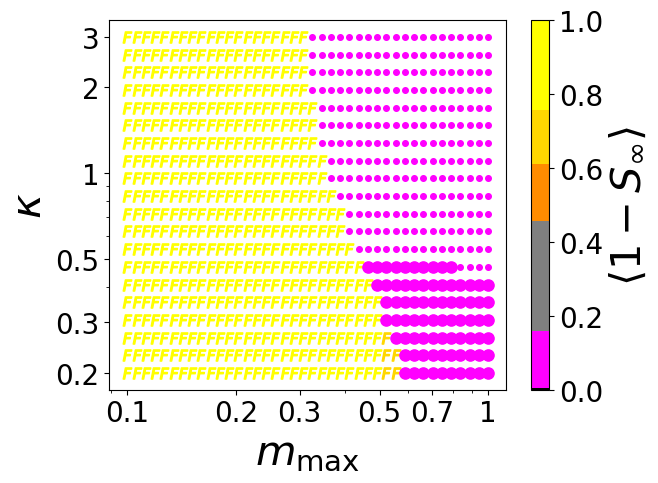

In [7]:
PlotSIRSm_HeatmapOfLimCycleMean_mmax_vs_fraction(AddedLabel, MethodLabel)

plt.savefig(f'img/SIRSm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.pdf', bbox_inches='tight')
#plt.legend()
plt.show()

### Bifurcation Diagram 1-S for diff mm_max and Ratefrac

In [76]:
mmax_valueList = [
    [0.3, 0.4],
    [0.4, 0.5],
    [0.5, 0.6],
    [0.6, 0.8]
]

fraction = [.8,.52,.48,.3]
fraction = [1, .5, .3, .2]
fraction = [2,.5,.3,.2]

In [81]:
Peaks = np.zeros((len(mmax_valueList),len(fraction),1000,2))

SetInCondfullSIRS(epsi, p, InInfComp)

Counter_Max = 0
for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
    for k in range(len(fraction)):

        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] # alpha_crit/fraction[k]
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k] # C*alpha_crit/fraction[k]
        p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
        cut = int(p['tmax']/p['stepsize']*7/10)

        counter = 0
        for mmax in np.linspace(min(mmax_values),max(mmax_values),30):
            p['mmax'] = mmax

            try: 
                m = model(**p)
                times, Data = m.run()
                S = Data[0,cut:]

                if(np.all(np.array(S[-10:-1])==np.full(9,S[-1]))): 
                    Peaks[mmax_val_idx, k, counter, 0] = mmax
                    Peaks[mmax_val_idx, k, counter, 1] = 1-S[-1]
                    counter += 1
                else:
                    max_idces, _ = scp.signal.find_peaks(1-S)
                    min_idces, _ = scp.signal.find_peaks(S-1)
                    Rinf_maxvalues = set([f"{1-S[idx]:.4f}" for idx in max_idces]) # Only keep values that difer by at least 0.001 (set eliminates equal values)
                    Rinf_minvalues = set([f"{1-S[idx]:.4f}" for idx in min_idces])

                    for Rinf in Rinf_maxvalues:
                        Peaks[mmax_val_idx, k, counter, 0] = mmax # mmax value is only assigned if there is a peak, else it stays at 0 and is not plotted later
                        Peaks[mmax_val_idx, k, counter, 1] = Rinf
                        counter += 1
                    for Rinf in Rinf_minvalues: 
                        Peaks[mmax_val_idx, k, counter, 0] = mmax
                        Peaks[mmax_val_idx, k, counter, 1] = Rinf
                        counter += 1
            except RuntimeError as errormessage:
                print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
                pass
        if(counter>Counter_Max): Counter_Max = counter
        print(k+1,'/',len(fraction))
    print('>>>',mmax_val_idx+1,'/',len(mmax_valueList))

print('Maximum of points on a plot =',Counter_Max)

np.save('Data/DataSIRSm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions.npy', Peaks)

1 / 4
2 / 4
3 / 4
4 / 4
>>> 1 / 4
1 / 4
2 / 4
3 / 4
4 / 4
>>> 2 / 4
1 / 4
2 / 4
3 / 4
4 / 4
>>> 3 / 4
1 / 4
2 / 4
3 / 4
4 / 4
>>> 4 / 4
Maximum of points on a plot = 186


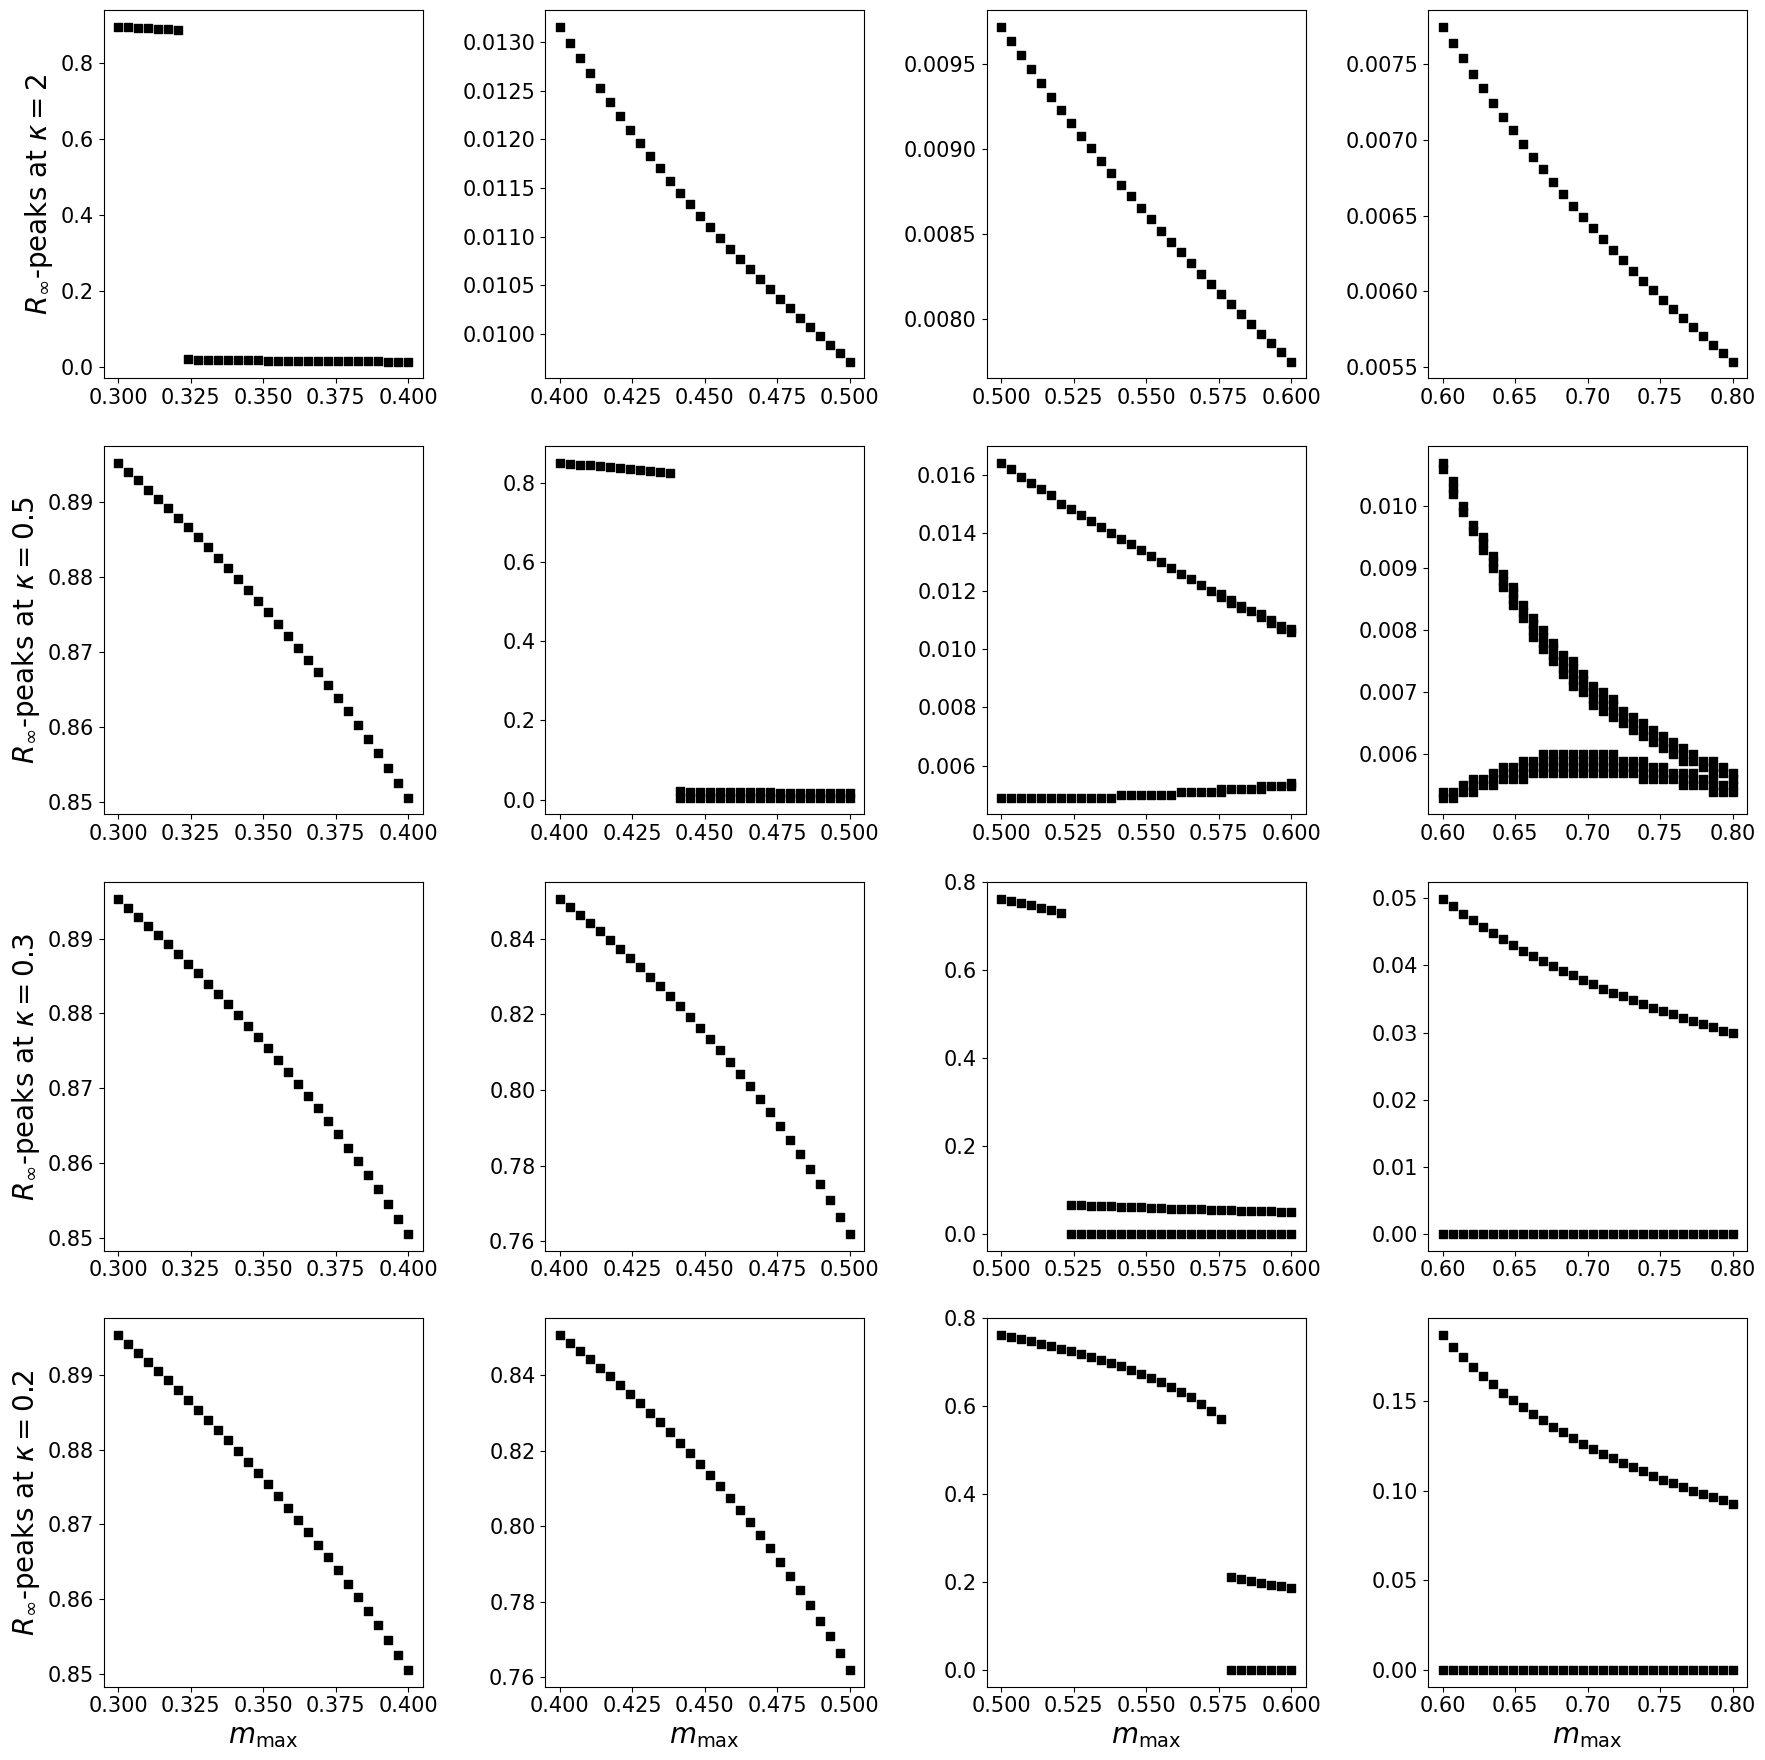

In [7]:
Peaks = np.load('Data/DataSIRSm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions.npy')

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for mmax_val_idx in range(len(mmax_valueList)):
    for k in range(len(fraction)):

        ax = axes[k, mmax_val_idx]

        for counter in range(len(Peaks[mmax_val_idx,k,:,:])): 
            mmax = Peaks[mmax_val_idx, k, counter, 0]
            if(mmax!=0):
                R_inf = Peaks[mmax_val_idx, k, counter, 1]
                ax.scatter(mmax, R_inf, marker=',', c='k')
        
        if(k==3): ax.set_xlabel(r'$m_{\rm max}$')
    
        if(mmax_val_idx==0): ax.set_ylabel(rf'$R_\infty$-peaks at $\kappa=${fraction[k]}')

plt.tight_layout()
plt.savefig('img/SIRSm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions_4x4.pdf', bbox_inches='tight')
plt.show()

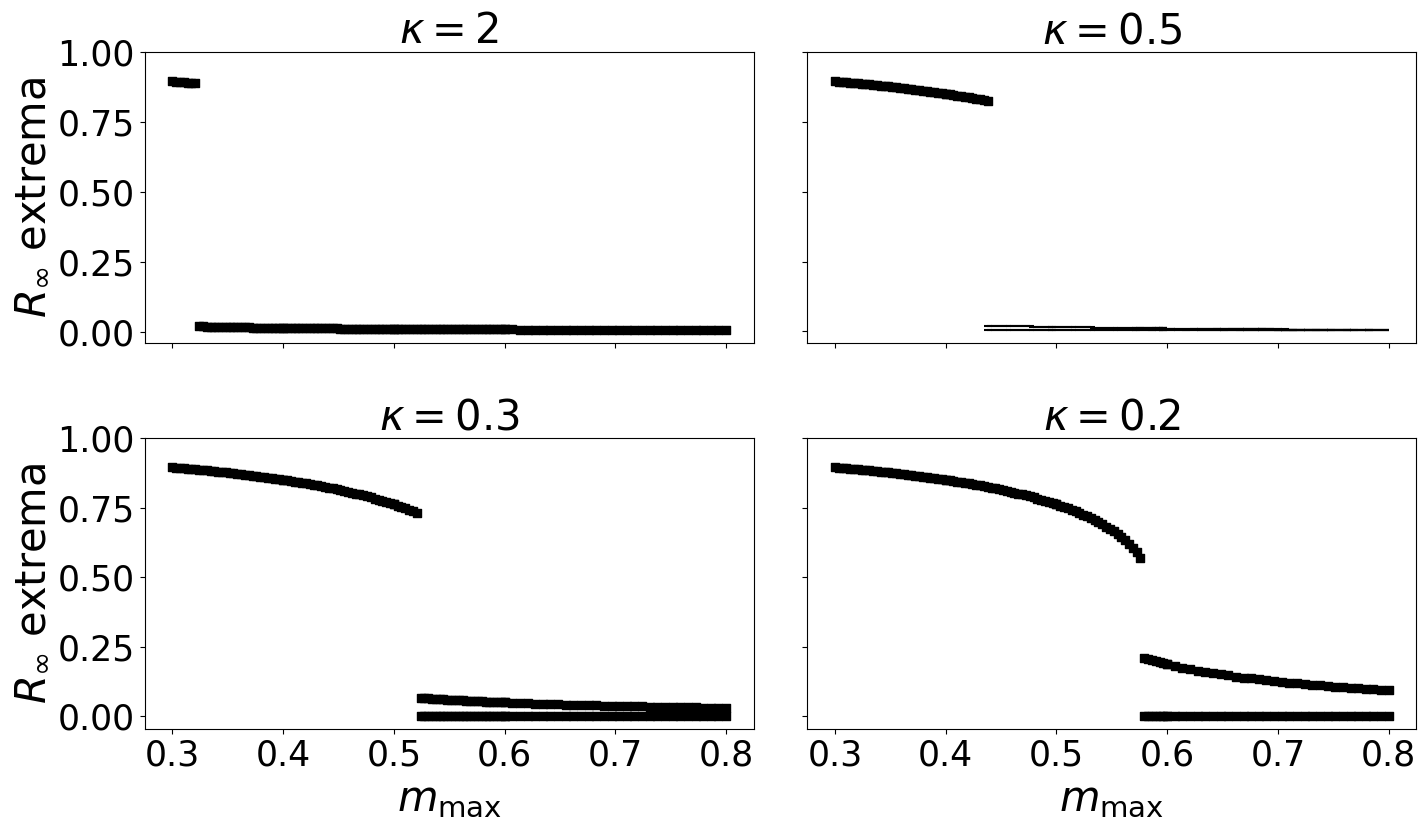

In [81]:
Peaks = np.load('Data/DataSIRSm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions.npy')

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for mmax_val_idx in range(len(mmax_valueList)):
    for k in range(len(fraction)):

        ax = axes[k//2, k%2]

        for counter in range(len(Peaks[mmax_val_idx,k,:,:])): 
            mmax = Peaks[mmax_val_idx, k, counter, 0]
            if(mmax!=0):
                R_inf = Peaks[mmax_val_idx, k, counter, 1]
                if(fraction[k]==0.5 and mmax>0.44): marker = 0 # to be able to see small limit cycle
                else: marker = ','
                ax.scatter(mmax, R_inf, marker=marker, c='k')
        
        if(k//2==1): ax.set_xlabel(r'$m_{\rm max}$')
    
        if(mmax_val_idx==0): 
            ax.set_title(rf'$\kappa=${fraction[k]}')
            if(k%2==0): ax.set_ylabel(rf'$R_\infty$ extrema')
            else: ax.tick_params(labelleft=False) 
            ax.set_xticks([.3,.4,.5,.6,.7,.8], labels=[.3,.4,.5,.6,.7,.8])
            if(k//2==0): ax.tick_params(labelbottom=False)
        ax.set_yticks([0,.25,.5,.75,1])
plt.tight_layout()
plt.savefig('img/SIRSm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

### Periodicity of Long term behavior

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_27000\2966509685.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


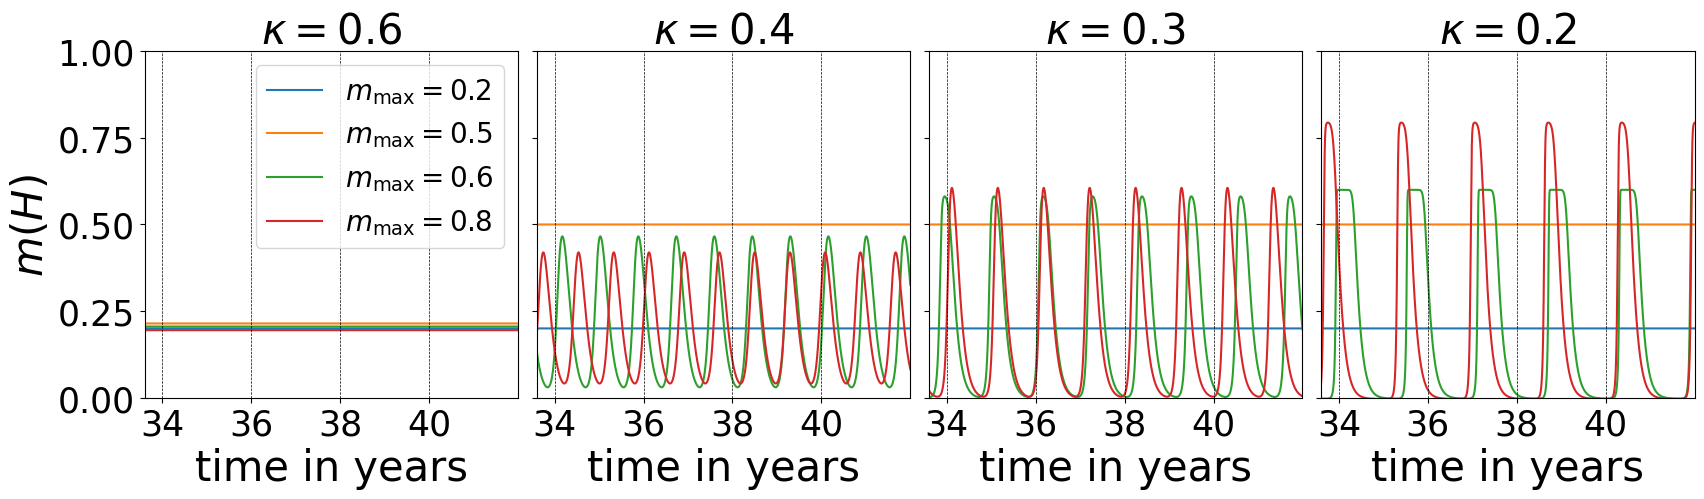

In [52]:
fraction = [.6,.4,.3,.2]
mmax_values = [.2,.5,.6,.8] #,1]
COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(mmax_values)]

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), gridspec_kw={'wspace':0.05})

for k in range(len(fraction)):

    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k] # alpha_crit/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k] # C*alpha_crit/fraction[k]
    p['tmax'] = 42*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*8/10)

    ######################################################
    
    ax_mit = axes[k]

    for mmax in mmax_values:
        p['mmax'] = mmax
        try: 
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H_1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            mitig =  mmax * m.m_normalized(H)
            
            ax_mit.plot(times/360, mitig, label=r'$m_{\rm max}=$'+f'{mmax}', c=COL[mmax_values.index(mmax)])
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass

    for i in range(int(min(times)/360+1), int(max(times)/360), 2): ax_mit.axvline(i, ls='--', c='k', lw=0.5)

    ax_mit.set_title(rf'$\kappa=${fraction[k]}')
    ax_mit.set_xlabel(r'time in years')  
    ax_mit.set_ylim(0,1)
    ax_mit.set_xlim(min(times)/360,max(times)/360)
    ax_mit.set_xticks(np.arange(int(min(times)/360)+1, int(max(times)/360)+1, 2))
    ax_mit.set_xlabel('time in years')

    ####################
    if(k==0): ax_mit.set_ylabel(r'$m(H)$')
    else: ax_mit.tick_params(labelleft=False)
    if(k==0): ax_mit.legend()

plt.tight_layout()
plt.savefig('img/SIRSm_Periodicity_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20